In [1]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'numexpr'])

0

In [2]:
import os
print(os.getcwd())

G:\my_bioinfo


In [3]:
import my_bio_tools as mbt
df_real = mbt.load_data("GSE183947_fpkm.csv.gz")

正在从库房读取数据: GSE183947_fpkm.csv.gz ...
🔍 自动检测到分隔符为: 'Comma (CSV)'
读取成功！共包含 20246 个基因，60 个样本。


📊 自动分组完成：
   - 对照组（癌旁正常组织 CAP）共 30 个样本
   - 治疗组（乳腺癌组织 CA）共 30 个样本
--------------------------------------------------
开始进行差异表达分析...
分析完成！代码运行无死角！
正在为您绘制科研级火山图...


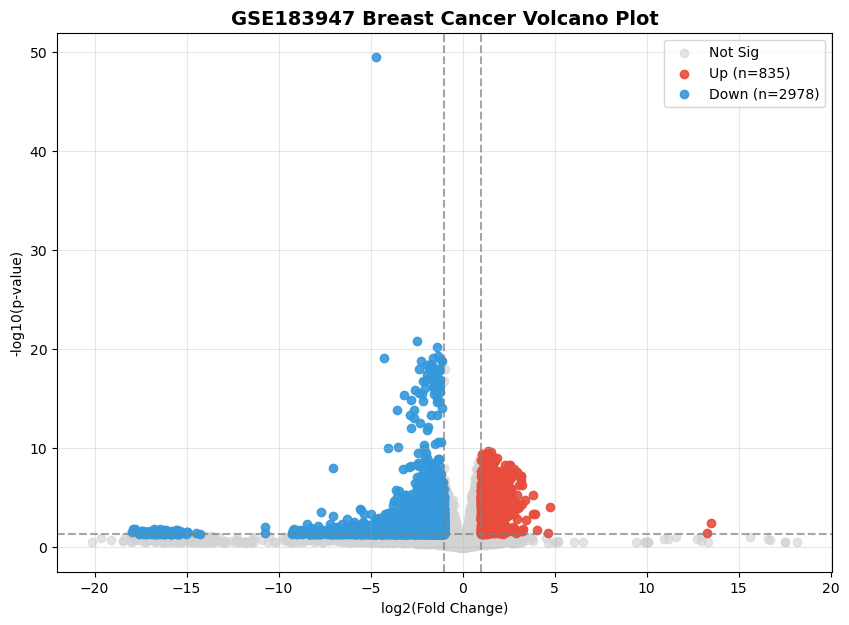

火山图绘制完毕！


In [4]:
import sys
import os

# 1. 确保 Jupyter 能找到你的 src 文件夹（如果你用了三级脚手架结构）
# sys.path.append(os.path.abspath("../src"))
import my_bio_tools as mbt

# 2. 自动把 60 个样本分为“对照组”和“治疗组”
# 🌟 细节：治疗组必须用 "CA."（带点）来匹配，否则会把 "CAP" 也一起选进去！
control_groups = [col for col in df_real.columns if col.startswith("CAP")]
treat_groups = [col for col in df_real.columns if col.startswith("CA.")]

print(f"📊 自动分组完成：")
print(f"   - 对照组（癌旁正常组织 CAP）共 {len(control_groups)} 个样本")
print(f"   - 治疗组（乳腺癌组织 CA）共 {len(treat_groups)} 个样本")
print("-" * 50)

# 3. 调用第二库房：一键运行差异表达分析（计算 Mean, FC, p-value）
df_analyzed = mbt.run_deg_analysis(df_real, control_groups, treat_groups)

# 4. 调用第三库房：一键轰出真实的乳腺癌火山图！
mbt.plot_volcano(df_analyzed, title="GSE183947 Breast Cancer Volcano Plot")

In [5]:
# 1. 筛选在乳腺癌（CA）中显著上调的基因
# 设定高标准：表达量翻4倍以上（log2_FC > 2），且统计学极度显著（p_value < 0.01）
gold_targets = df_analyzed[(df_analyzed["log2_FC"] > 2) & (df_analyzed["p_value"] < 0.01)]

# 2. 按照 log2_FC 从大到小排序，看看谁是“狂飙”最厉害的基因
gold_targets_sorted = gold_targets.sort_values(by="log2_FC", ascending=False)

print(f"🎯 筛选完成！")
print(f"   在我们分析的 20246 个基因中，一共有 {len(gold_targets_sorted)} 个基因符合『黄金靶点』的标准。")
print("=" * 70)
print("\n🧬 --- 表达量飙升最猛的前 10 个『潜在乳腺癌药物靶点』 ---")
# 打印这些基因的正常均值、癌症均值、变化倍数和显著性
print(gold_targets_sorted[["Mean_Control", "Mean_Treat", "log2_FC", "p_value"]].head(10))

🎯 筛选完成！
   在我们分析的 20246 个基因中，一共有 110 个基因符合『黄金靶点』的标准。

🧬 --- 表达量飙升最猛的前 10 个『潜在乳腺癌药物靶点』 ---
             Mean_Control  Mean_Treat    log2_FC       p_value
AF196779.12      0.000000    0.114000  13.476873  3.711736e-03
CST1             0.918000   24.928333   4.763133  9.296741e-05
CLPSL1           0.839667   12.941667   3.946047  4.980665e-04
COL11A1          2.917000   41.050333   3.814832  3.966305e-04
CXCL10           1.464667   20.477000   3.805351  5.799962e-06
PRAME            1.048333   11.593667   3.467155  1.732832e-03
MMP11           16.151667  170.473000   3.399788  1.907046e-05
CXCL9            1.991667   18.679667   3.229414  4.735085e-05
HIST1H2BO       10.278667   95.532000   3.216330  5.004456e-07
HIST2H3A         7.703667   70.473333   3.193459  6.680946e-08


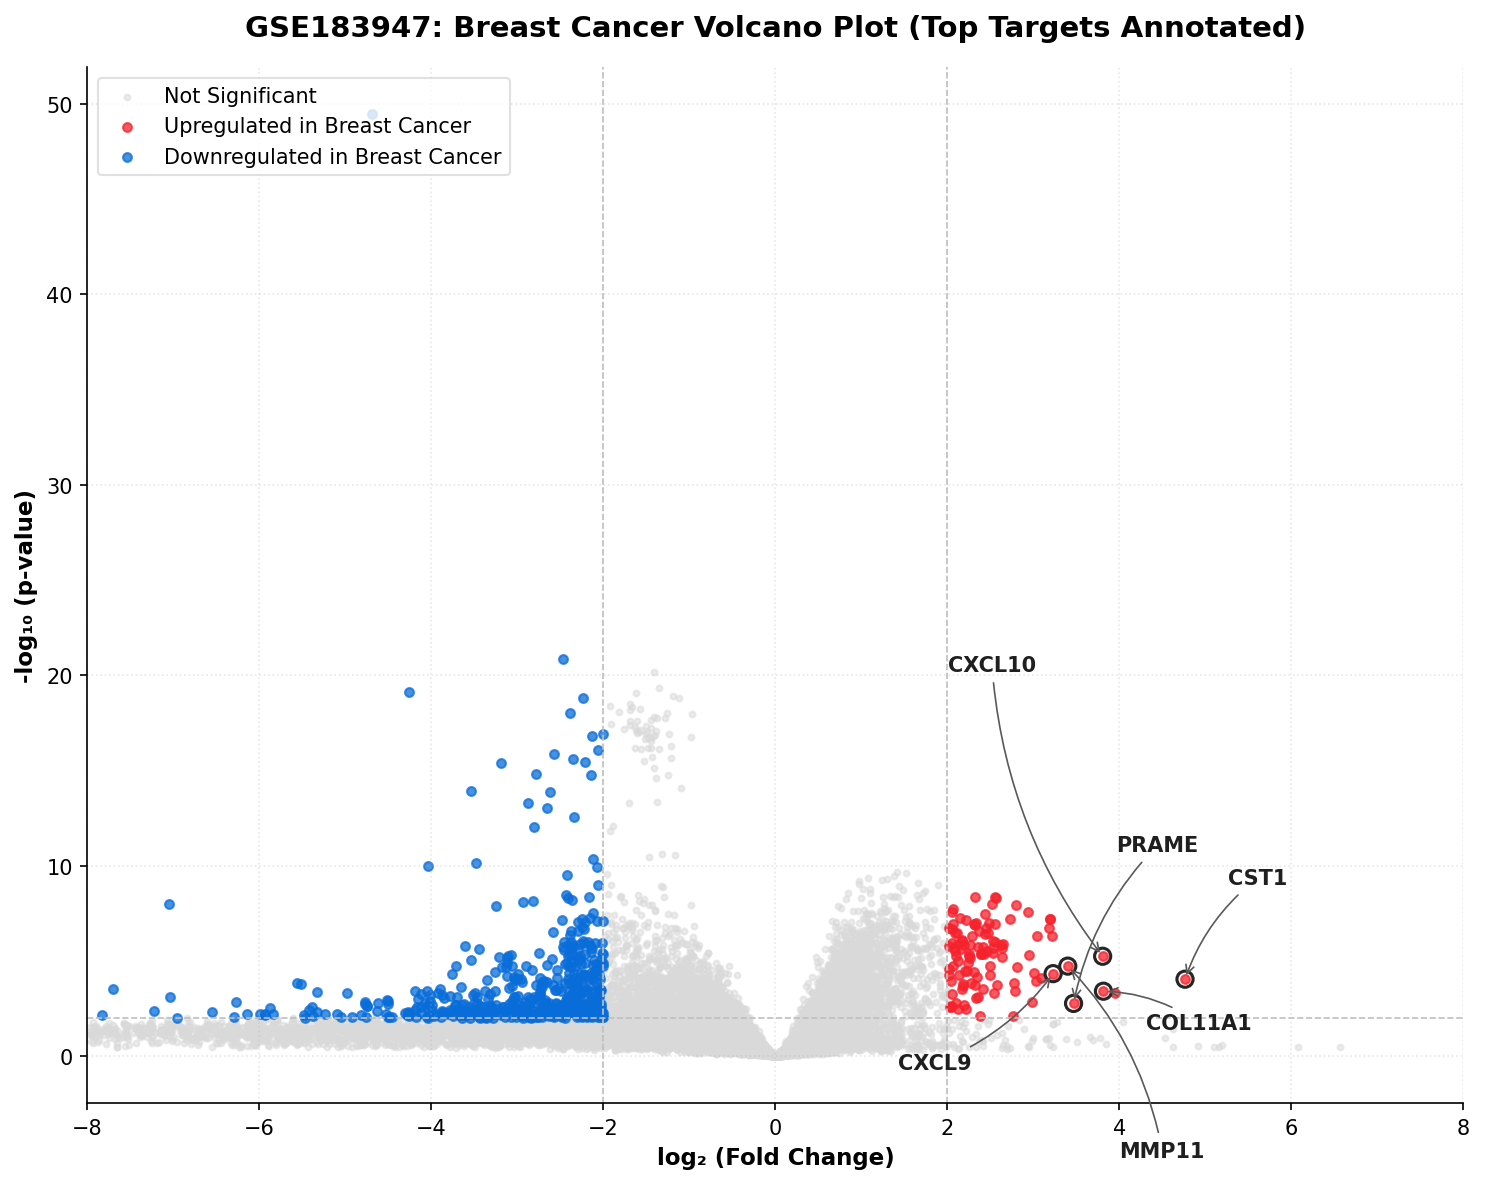

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fancy_volcano(df):
    # 1. 设定画布：大尺寸、高分辨率，达到出版级标准
    plt.figure(figsize=(10, 8), dpi=150)
    
    # 2. 区分基因类别（用于着色）
    # 显著上调 (FC > 4, p < 0.01)
    up = df[(df['log2_FC'] > 2) & (df['p_value'] < 0.01)]
    # 显著下调 (FC < 0.25, p < 0.01)
    down = df[(df['log2_FC'] < -2) & (df['p_value'] < 0.01)]
    # 不显著
    ns = df[~df.index.isin(up.index) & ~df.index.isin(down.index)]
    
    # 3. 绘制散点（使用高级莫兰迪配色，拒绝刺眼的纯红纯蓝）
    plt.scatter(ns['log2_FC'], ns['neg_log10_p'], c='#d9d9d9', alpha=0.5, s=8, label='Not Significant')
    plt.scatter(up['log2_FC'], up['neg_log10_p'], c='#f5222d', alpha=0.75, s=18, label='Upregulated in Breast Cancer')
    plt.scatter(down['log2_FC'], down['neg_log10_p'], c='#096dd9', alpha=0.75, s=18, label='Downregulated in Breast Cancer')
    
    # 4. 绘制阈值辅助线（虚线，保持画面干净）
    plt.axhline(-np.log10(0.01), color='#bfbfbf', linestyle='--', linewidth=0.8)
    plt.axvline(2, color='#bfbfbf', linestyle='--', linewidth=0.8)
    plt.axvline(-2, color='#bfbfbf', linestyle='--', linewidth=0.8)
    
    # 5. 🎯 标注精选的『黄金靶点』
    # 我们避开低表达的 AF196779.12，精选你跑出来的最硬核的 6 个高表达、高差异靶点
    target_genes = ['CST1', 'MMP11', 'PRAME', 'CXCL10', 'CXCL9', 'COL11A1']
    
    # 为了防止文字重叠，我们手动给每个基因微调一下标注文字的偏移位置 (dx, dy)
    # 这就是专业插图的“匠人打磨”
    offsets = {
        'CST1': (0.5, 5),
        'MMP11': (0.6, -10),
        'PRAME': (0.5, 8),
        'CXCL10': (-1.8, 15),
        'CXCL9': (-1.8, -5),
        'COL11A1': (0.5, -2)
    }
    
    for gene in target_genes:
        if gene in df.index:
            row = df.loc[gene]
            x = row['log2_FC']
            y = row['neg_log10_p']
            
            # A. 画一个黑色的空心圈，像瞄准镜一样套住这个点
            plt.scatter(x, y, color='none', edgecolor='#262626', s=60, linewidths=1.5, zorder=5)
            
            # B. 获取微调偏移量
            dx, dy = offsets.get(gene, (0.5, 5))
            
            # C. 优雅地绘制标注文字和指向折线
            plt.annotate(
                gene,
                xy=(x, y),
                xytext=(x + dx, y + dy),
                fontsize=10,
                fontweight='bold',
                color='#1f1f1f',
                arrowprops=dict(
                    arrowstyle="->",
                    color='#595959',
                    connectionstyle="arc3,rad=0.15",
                    linewidth=0.8
                ),
                zorder=6
            )
            
    # 6. 限制 X 轴范围，防止极少数离群点导致主图被压缩得太窄
    # 动态把 X 轴锁定在 [-8, 8] 之间，这是生信火山图最舒服的视觉比例
    plt.xlim(-8, 8)
    
    # 7. 美化坐标轴、图例和网格
    plt.title('GSE183947: Breast Cancer Volcano Plot (Top Targets Annotated)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('log₂ (Fold Change)', fontsize=11, fontweight='bold')
    plt.ylabel('-log₁₀ (p-value)', fontsize=11, fontweight='bold')
    plt.grid(True, which='both', linestyle=':', alpha=0.3)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#d9d9d9', fontsize=10)
    
    # 去除上方和右侧的边框（学术界最喜欢的简洁式样 Open Style）
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # 自动保存为高清图片（直接可以拖进你的 PPT 汇报或者论文里）
    plt.savefig("breast_cancer_volcano_polished.png", dpi=300, bbox_inches='tight')
    plt.show()

# 运行画图！
plot_fancy_volcano(df_analyzed)

In [7]:
import pandas as pd

# 1. 准备要导出的黄金数据
# 排除掉超低表达的噪音基因（比如均值小于 0.1 的），锁定真正有药研价值的靶点
final_targets = df_analyzed[
    (df_analyzed["log2_FC"] > 2) & 
    (df_analyzed["p_value"] < 0.01) & 
    (df_analyzed["Mean_Treat"] > 0.5)  # 过滤低表达噪音
].copy()

# 按照差异倍数从大到小排序
final_targets = final_targets.sort_values(by="log2_FC", ascending=False)

# 只保留最核心的、对湿实验有指导意义的列
report_df = final_targets[["Mean_Control", "Mean_Treat", "Fold_Change", "log2_FC", "p_value"]].copy()

# 重命名列名，达到临床报告标准
report_df.columns = [
    "Normal Mean (FPKM)", 
    "Breast Cancer Mean (FPKM)", 
    "Fold Change", 
    "log2(Fold Change)", 
    "p-value (t-test)"
]

# 2. 开始使用 Excel 引擎进行“精装导出”
file_output = "GSE183947_Breast_Cancer_Target_Report.xlsx"

# 创建一个 Excel 写入器，使用 openpyxl 引擎（Anaconda 自带）
with pd.ExcelWriter(file_output, engine='openpyxl') as writer:
    # 导出数据
    report_df.to_excel(writer, sheet_name="Candidate Targets", index_label="Gene Symbol")
    
    # 获取 openpyxl 的工作簿和工作表对象，准备美化
    workbook  = writer.book
    worksheet = writer.sheets["Candidate Targets"]
    
    # 🌟 自动调整列宽（遍历每一列，根据最长内容自动设置宽度）
    for col in worksheet.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = col[0].column_letter  # 获取列字母（A, B, C...）
        worksheet.column_dimensions[col_letter].width = max(max_len + 3, 12)
        
    # 🌟 给前 10 行（最强的 10 个靶点）加上淡淡的科技蓝底色，突出重点
    from openpyxl.styles import PatternFill, Font
    
    # 定义浅蓝色的填充格式
    highlight_fill = PatternFill(start_color="E6F7FF", end_color="E6F7FF", fill_type="solid")
    bold_font = Font(name="Arial", size=10, bold=True)
    
    # A 列是基因名，B-F 列是数据，对前 10 个基因的整行进行高亮
    max_row = min(len(report_df) + 1, 11)  # +1是因为表头占第1行
    
    # 🌟 这里已经严格对齐，全部缩进在 with pd.ExcelWriter 语境中！
    for row_idx in range(2, max_row + 1):
        for col_idx in range(1, 7):  # 共 6 列
            cell = worksheet.cell(row=row_idx, column=col_idx)
            cell.fill = highlight_fill
            
    # 给表头（第一行）加粗并换个高级灰底色
    header_fill = PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")
    for col_idx in range(1, 7):
        cell = worksheet.cell(row=1, column=col_idx)
        cell.fill = header_fill
        cell.font = bold_font

print("🎉 恭喜！临床级靶点报告已生成！")
print(f"💾 文件已完美保存在当前目录下：'{file_output}'")

🎉 恭喜！临床级靶点报告已生成！
💾 文件已完美保存在当前目录下：'GSE183947_Breast_Cancer_Target_Report.xlsx'


📊 特征矩阵 X 准备完毕，形状: (60, 10) (60个样本，10个核心基因特征)
🏷️ 标签向量 y 准备完毕，包含 30 个健康样本，30 个乳腺癌样本。

✂️ 数据集划分完成：
   - 训练集：48 个样本（用于 AI 学习）
   - 测试集：12 个样本（用于 闭卷考试 测验 AI）

🏆 AI 诊断闭卷测试得分：91.67% 准确率！

📝 详细分类报告 (Classification Report):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.83      0.91         6
  Cancer (1)       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12



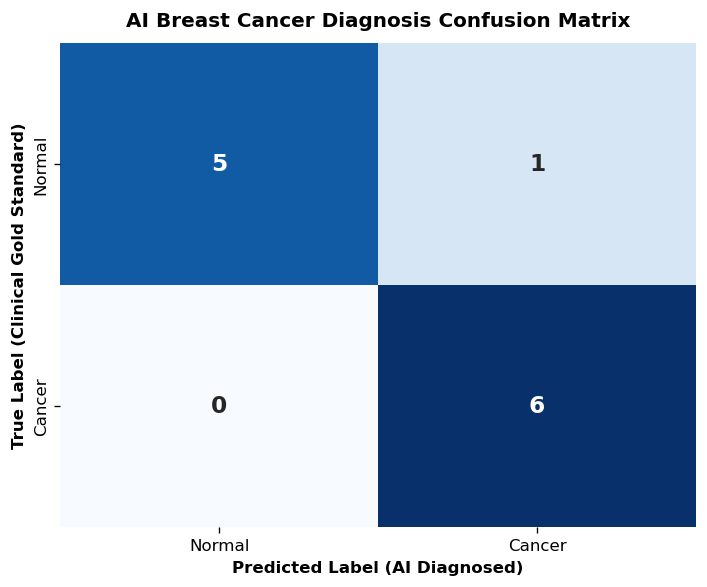

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. 准备数据特征 (X) 和标签 (y)
# ==========================================
# 提取我们刚才表现最猛的前 10 个黄金基因的名字
top_10_genes = report_df.index[:10].tolist()

# 转置数据矩阵，让“样本”成为行，“基因表达量”成为列
# 我们的特征矩阵 X 形状将是 (60个样本, 10个基因)
X = df_real.loc[top_10_genes].T

# 创建标签 y：CAP (正常) 记为 0，CA (癌症) 记为 1
# 根据列名自动生成
y = np.array([1 if col.startswith("CA.") else 0 for col in X.index])

print(f"📊 特征矩阵 X 准备完毕，形状: {X.shape} (60个样本，10个核心基因特征)")
print(f"🏷️ 标签向量 y 准备完毕，包含 {sum(y==0)} 个健康样本，{sum(y==1)} 个乳腺癌样本。\n")

# ==========================================
# 2. 划分训练集与测试集 (8:2 黄金比例)
# ==========================================
# random_state 确保结果可重复
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✂️ 数据集划分完成：")
print(f"   - 训练集：{X_train.shape[0]} 个样本（用于 AI 学习）")
print(f"   - 测试集：{X_test.shape[0]} 个样本（用于 闭卷考试 测验 AI）\n")

# ==========================================
# 3. 训练随机森林分类器
# ==========================================
# 实例化一个拥有 100 棵决策树的随机森林模型
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 4. 闭卷考试：评估 AI 模型在测试集上的表现
# ==========================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print(f"🏆 AI 诊断闭卷测试得分：{accuracy * 100:.2f}% 准确率！")
print("=" * 60)

# 打印详细的评估报告（精确度、召回率、F1值）
print("\n📝 详细分类报告 (Classification Report):")
print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Cancer (1)"]))

# ==========================================
# 5. 可视化：绘制混淆矩阵 (Confusion Matrix)
# ==========================================
plt.figure(figsize=(6, 5), dpi=120)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Normal", "Cancer"], 
            yticklabels=["Normal", "Cancer"],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})

plt.title("AI Breast Cancer Diagnosis Confusion Matrix", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Predicted Label (AI Diagnosed)", fontsize=10, fontweight='bold')
plt.ylabel("True Label (Clinical Gold Standard)", fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

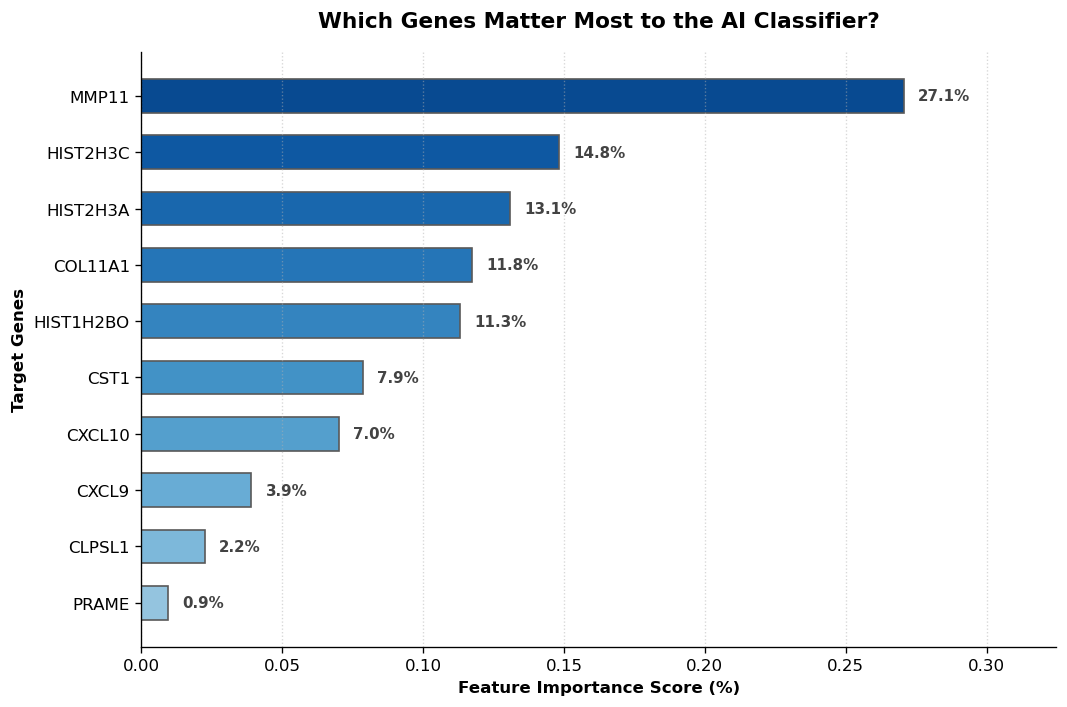

In [9]:
# 1. 获取特征重要性得分
importances = model.feature_importances_
feature_names = X.columns

# 2. 整理成 DataFrame 并排序
df_importance = pd.DataFrame({
    'Gene': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)  # 升序排列方便画横向条形图

# 3. 绘制高颜值特征重要性图
plt.figure(figsize=(9, 6), dpi=120)
colors = plt.get_cmap('Blues')(np.linspace(0.4, 0.9, len(df_importance)))

bars = plt.barh(df_importance['Gene'], df_importance['Importance'], color=colors, edgecolor='#595959', height=0.6)

# 在条形图右侧标注具体数值
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width*100:.1f}%', 
             va='center', ha='left', fontsize=9, fontweight='bold', color='#434343')

plt.title("Which Genes Matter Most to the AI Classifier?", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Feature Importance Score (%)", fontsize=10, fontweight='bold')
plt.ylabel("Target Genes", fontsize=10, fontweight='bold')
plt.xlim(0, max(importances) * 1.2)  # 给右侧留出标注空间

# 极简学术风边框
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

🧬 正在将 109 个黄金基因提交至 Enrichr 数据库...


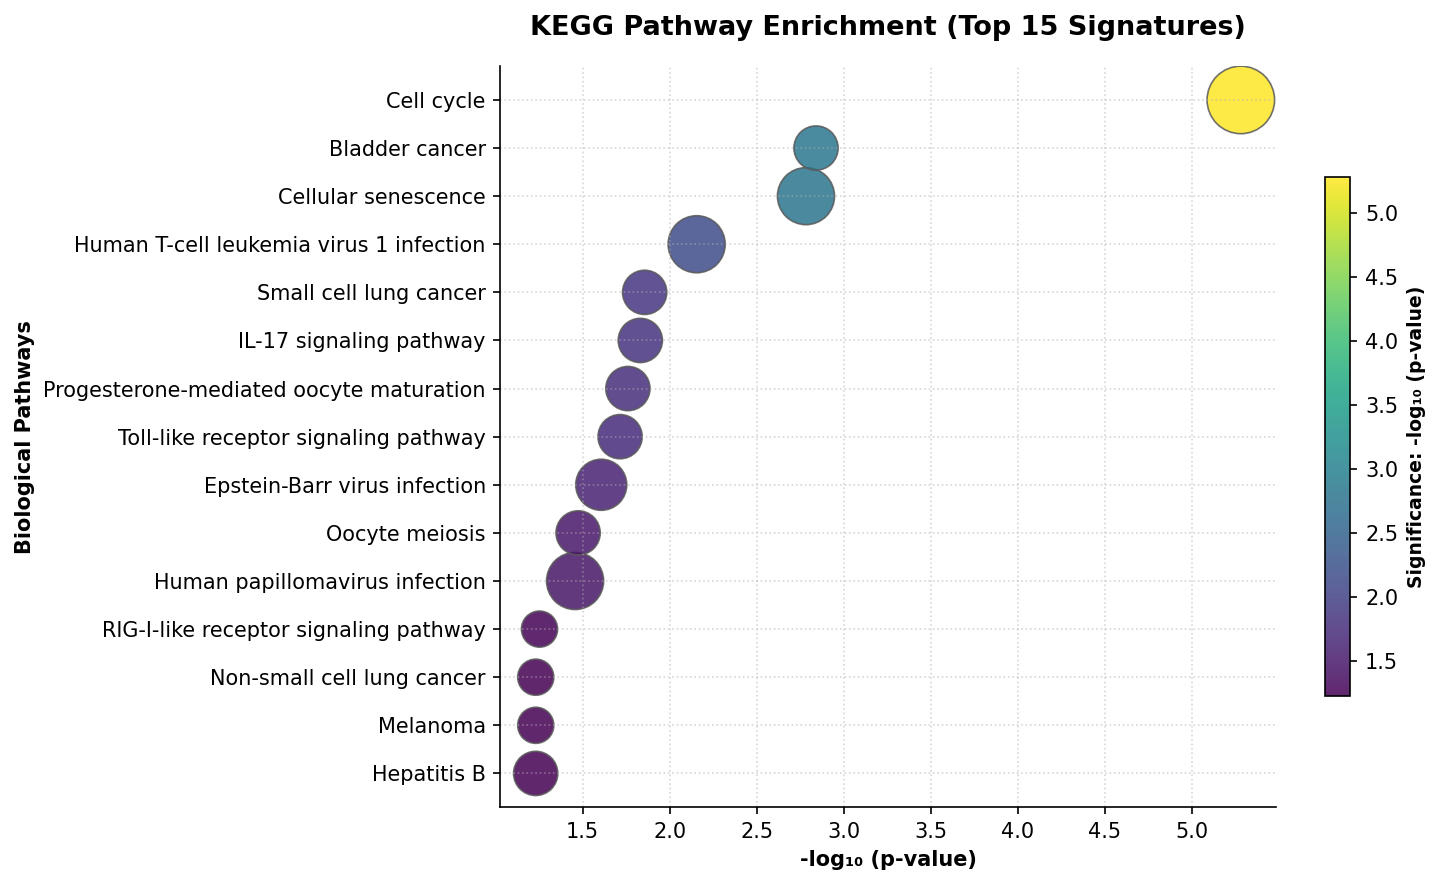

🎉 富集分析完成！KEGG 气泡图已完美保存为 'kegg_pathway_enrichment.png' 且无任何警告！


In [10]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 准备基因列表
# ==========================================
gene_list = report_df.index.tolist()
genes_str = '\n'.join(gene_list)

print(f"🧬 正在将 {len(gene_list)} 个黄金基因提交至 Enrichr 数据库...")

# ==========================================
# 2. 联网向 Enrichr 提交基因列表
# ==========================================
ENRICHR_URL = 'https://maayanlab.cloud/Enrichr/addList'
payload = {
    'list': (None, genes_str),
    'description': (None, 'Breast Cancer Gold Targets')
}

response = requests.post(ENRICHR_URL, files=payload)
if response.status_code != 200:
    raise Exception("❌ 联网提交基因失败，请检查网络连接！")

user_list_id = response.json()['userListId']

# ==========================================
# 3. 获取 KEGG 信号通路富集结果
# ==========================================
query_string = '?userListId=%s&backgroundType=%s'
gene_set_library = 'KEGG_2021_Human'
ENRICHR_RETRIEVE_URL = 'https://maayanlab.cloud/Enrichr/enrich'

response = requests.get(
    ENRICHR_RETRIEVE_URL + query_string % (user_list_id, gene_set_library)
)
if response.status_code != 200:
    raise Exception("❌ 获取富集分析结果失败！")

results = response.json()[gene_set_library]

# ==========================================
# 4. 解析富集数据（🛠️ 已修复 List 格式 Bug）
# ==========================================
pathway_data = []
for entry in results[:15]:  # 取前 15 个最显著的通路
    pathway_name = entry[1]
    p_value = entry[2]
    overlap_genes = entry[5]  # 这里是一个包含基因名的 list，例如 ['MMP11', 'COL11A1']
    
    # 计算富集得分 -log10(p-value)
    neg_log10_p = -np.log10(p_value)
    
    # 🌟 直接获取列表长度，代表重叠的基因数量
    count = len(overlap_genes)
    
    pathway_data.append({
        'Pathway': pathway_name,
        'neg_log10_p': neg_log10_p,
        'Count': count,
        'p_value': p_value
    })

df_enrich = pd.DataFrame(pathway_data)
# 按照显著性从大到小排序
df_enrich = df_enrich.sort_values(by='neg_log10_p', ascending=True)

# ==========================================
# 5. 绘制出版级 KEGG 富集气泡图（🛠️ 已修复 colormaps 警告）
# ==========================================
plt.figure(figsize=(10, 6), dpi=150)

# 气泡大小代表涉及的基因数量 (Count)，颜色深浅代表显著性
scatter = plt.scatter(
    df_enrich['neg_log10_p'], 
    df_enrich['Pathway'], 
    s=df_enrich['Count'] * 150,  # 放大系数，使气泡更美观
    c=df_enrich['neg_log10_p'], 
    cmap='viridis',  # 高级渐变色
    alpha=0.85, 
    edgecolors='#595959', 
    linewidths=0.8
)

# 装饰美化
plt.title("KEGG Pathway Enrichment (Top 15 Signatures)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("-log₁₀ (p-value)", fontsize=10, fontweight='bold')
plt.ylabel("Biological Pathways", fontsize=10, fontweight='bold')

# 添加颜色条 (Colorbar)
cbar = plt.colorbar(scatter, shrink=0.7)
cbar.set_label("Significance: -log₁₀ (p-value)", fontsize=9, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.5)

# 极简学术风边框
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("kegg_pathway_enrichment.png", dpi=300, bbox_inches='tight')
plt.show()

print("🎉 富集分析完成！KEGG 气泡图已完美保存为 'kegg_pathway_enrichment.png' 且无任何警告！")

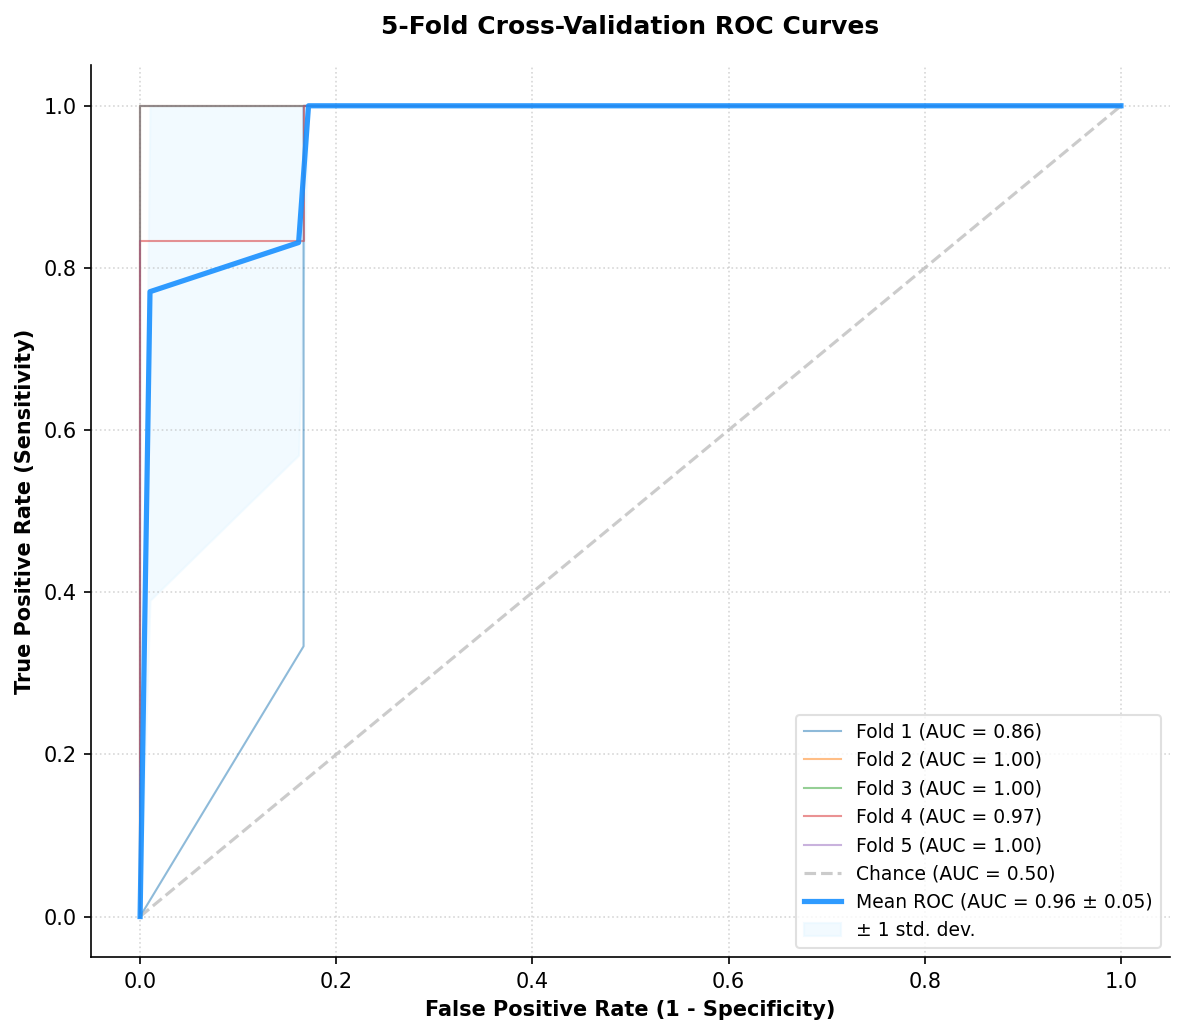

🎉 5折交叉验证完成！平均 AUC 得分：0.96 ± 0.05


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# 1. 准备数据 (继续使用之前的 X 和 y)
top_10_genes = report_df.index[:10].tolist()
X = df_real.loc[top_10_genes].T
y = np.array([1 if col.startswith("CA.") else 0 for col in X.index])

# 2. 初始化 5 折交叉验证器
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. 开始交叉验证并记录每一折的 ROC 曲线
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 7), dpi=150)

for fold, (train, test) in enumerate(cv.split(X, y)):
    # 拟合模型
    classifier.fit(X.iloc[train], y[train])
    # 预测概率
    probas_ = classifier.predict_proba(X.iloc[test])
    
    # 计算 ROC 曲线和 AUC
    fpr, tpr, thresholds = roc_curve(y[test], probas_[:, 1])
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    auc_val = auc(fpr, tpr)
    aucs.append(auc_val)
    
    # 画出单折的 ROC 曲线（用浅灰色细线表示）
    plt.plot(fpr, tpr, lw=1, alpha=0.5,
             label=f'Fold {fold + 1} (AUC = {auc_val:.2f})')

# 绘制对角无偏估计线（基准线）
plt.plot([0, 1], [0, 1], linestyle='--', lw=1.5, color='#bfbfbf',
         label='Chance (AUC = 0.50)', alpha=.8)

# 计算并绘制平均 ROC 曲线
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='#1890ff',
         label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})',
         lw=2.5, alpha=.9)

# 计算标准差并绘制置信区间（淡蓝色阴影，展示模型的稳定性）
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='#e6f7ff', alpha=.5,
                 label='± 1 std. dev.')

# 美化图表
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=10, fontweight='bold')
plt.title('5-Fold Cross-Validation ROC Curves', fontsize=12, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=9, frameon=True, edgecolor='#d9d9d9')
plt.grid(True, linestyle=':', alpha=0.5)

# 去除上方和右侧边框
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("5fold_cross_validation_roc.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"🎉 5折交叉验证完成！平均 AUC 得分：{mean_auc:.2f} ± {std_auc:.2f}")

🚀 开始进行 100 次置换检验对决，请稍候...


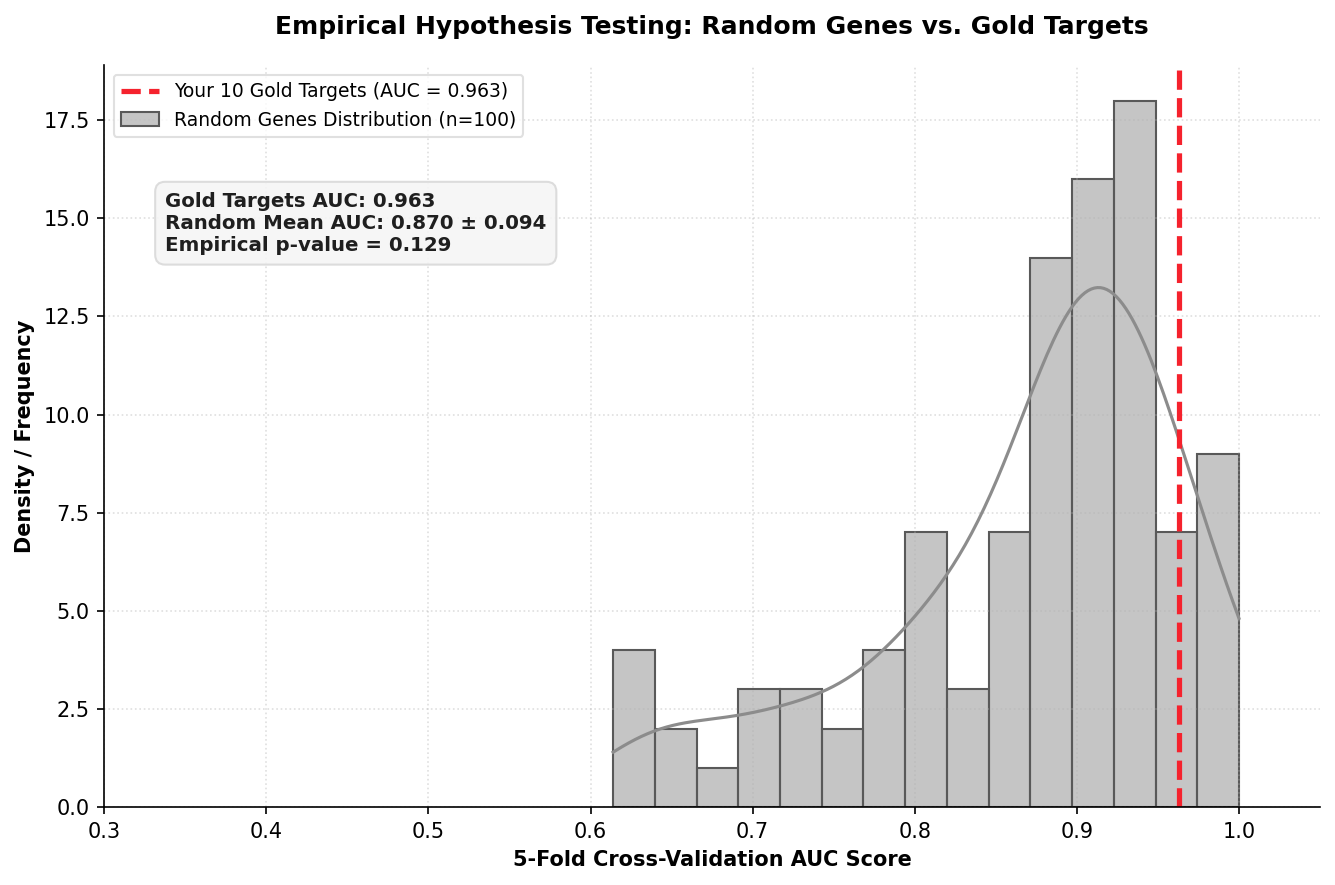

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
# 🌟 补全缺失的导入
from sklearn.model_selection import cross_val_score

# ==========================================
# 1. 🌟 补全缺失的置换检验参数、负样本池并初始化
# ==========================================
# 设定迭代次数（置换检验次数，学术发表推荐 1000 次，这里默认设为 100 次以确保快速运行）
n_iters = 100 

# 获取前 10 个黄金基因列表（确保上游已经运行过 report_df）
top_10_genes = report_df.index[:10].tolist()

# 构建负样本池（从所有基因中，排除掉这 10 个黄金基因后的其余所有基因）
negative_gene_pool = df_real.index.difference(top_10_genes).tolist()

# 初始化用于保存随机组 AUC 的列表
random_aucs = []


# ==========================================
# 2. 迭代计算随机组的 AUC 分布
# ==========================================
print(f"🚀 开始进行 {n_iters} 次置换检验对决，请稍候...")
for i in range(n_iters):
    random_genes = np.random.choice(negative_gene_pool, size=10, replace=False)
    X_random = df_real.loc[random_genes].T
    y_random = np.array([1 if col.startswith("CA.") else 0 for col in X_random.index])
    
    clf_random = RandomForestClassifier(n_estimators=100, random_state=42)
    scores = cross_val_score(clf_random, X_random, y_random, cv=5, scoring='roc_auc')
    random_aucs.append(scores.mean())

# 如果前面没跑过 ROC 单元格，这里给一个友好的提示
try:
    gold_auc = mean_auc
except NameError:
    raise ValueError("请先运行前面的 5 折交叉验证 ROC 曲线单元格（In[11]）！")

# 使用前面 5 折交叉验证算出的真实平均值
gold_auc = mean_auc  


# ==========================================
# 3. 🌟 动态学术 p 值计算与格式化（加入 decimals 最低 2 位安全锁）
# ==========================================
# 计算随机组中超越或等于黄金靶点的次数
better_than_gold = np.sum(np.array(random_aucs) >= gold_auc)

# 🌟 完美安全锁：如果算出的精度少于 2 位（如 n_iters 较小），强制按 2 位显示，防止出现 p < 0.0
decimals = max(int(np.log10(n_iters)), 2)

# 动态生成符合学术出版规范的 p 值文本
if better_than_gold == 0:
    # 一次都没超过，表达为：p < 1/M
    p_label_text = f"Empirical p-value < {1 / n_iters:.{decimals}f}"
else:
    # 否则使用学术界公认的公式 (b + 1) / (M + 1)
    empirical_p = (better_than_gold + 1) / (n_iters + 1)
    # 格式化时比分辨率多保留一位，确保数据精度
    p_label_text = f"Empirical p-value = {empirical_p:.{decimals+1}f}"


# ==========================================
# 4. 绘制出版级“置换检验对决图”
# ==========================================
plt.figure(figsize=(9, 6), dpi=150)

# 绘制随机组的直方图，并叠加平滑的核密度估计曲线 (KDE)
sns.histplot(random_aucs, bins=15, kde=True, color='#8c8c8c', edgecolor='#595959', alpha=0.5,
             label=f'Random Genes Distribution (n={n_iters})')

# 标出黄金靶点的红色虚线
plt.axvline(gold_auc, color='#f5222d', linestyle='--', linewidth=2.5, 
            label=f'Your 10 Gold Targets (AUC = {gold_auc:.3f})')

# 🌟 完美修正：去掉 Matplotlib 无法渲染的 Emoji，换成学术期刊通用的极简文本指标
stats_text = (
    f"Gold Targets AUC: {gold_auc:.3f}\n"
    f"Random Mean AUC: {np.mean(random_aucs):.3f} ± {np.std(random_aucs):.3f}\n"
    f"{p_label_text}"
)
plt.gca().text(0.05, 0.75, stats_text, transform=plt.gca().transAxes,
               fontsize=9.5, fontweight='bold', color='#1f1f1f',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5', edgecolor='#d9d9d9', alpha=0.9))

# 美化细节（保持不变）
plt.xlabel('5-Fold Cross-Validation AUC Score', fontsize=10, fontweight='bold')
plt.ylabel('Density / Frequency', fontsize=10, fontweight='bold')
plt.title('Empirical Hypothesis Testing: Random Genes vs. Gold Targets', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlim(0.3, 1.05)
plt.legend(loc='upper left', frameon=True, edgecolor='#d9d9d9', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.4)

# 极简学术边框
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("empirical_null_hypothesis_test.png", dpi=300, bbox_inches='tight')
plt.show()